# EMA 55 Crossover: Visualizer & Trade Log
# Target: +5% | Max Days: 8 | Regime Filter: Close > EMA 200

In [1]:
# 1. Imports and Setup
import pandas as pd
import numpy as np
import os
import glob
import random
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import warnings

warnings.filterwarnings('ignore')
display(HTML("<style>.container { width:100% !important; }</style>"))
plt.rcParams['figure.figsize'] = (24, 12)

DATA_DIR = r'D:\0dot1_Aug_2016_master\data\mstock_mtf_daily_data'


In [2]:
# 2. Backtest Engine & Indicator Logic
def calc_rsi(series, period):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

def backtest_ema_single(df, take_profit, time_stop):
    trades = []
    in_trade = False
    entry_price = 0
    entry_date = None
    days_held = 0
    
    for i in range(len(df)):
        row = df.iloc[i]
        
        if pd.isna(row['EMA_55']) or pd.isna(row['EMA_221']):
            continue
            
        if in_trade:
            days_held += 1
            exit_triggered = False
            exit_reason = ""
            
            profit_pct = (row['Close'] - entry_price) / entry_price
            
            if profit_pct >= take_profit:
                exit_triggered = True
                exit_reason = "Take Profit"
            elif days_held >= time_stop:
                exit_triggered = True
                exit_reason = "Time Stop"
            
            if exit_triggered:
                trades.append({
                    'Symbol': row['Symbol'],
                    'Entry_Date': entry_date,
                    'Entry_Price': entry_price,
                    'Exit_Date': row['Date'],
                    'Exit_Price': row['Close'],
                    'Return': profit_pct,
                    'Reason': exit_reason,
                    'Entry_RSI_5': entry_row['RSI_5'],
                    'Entry_RSI_14': entry_row['RSI_14'],
                    'Entry_RSI_34': entry_row['RSI_34'],
                    'Entry_EMA_55': entry_row['EMA_55'],
                    'Entry_EMA_221': entry_row['EMA_221']
                })
                in_trade = False
                days_held = 0
                
        if not in_trade and row['Setup_Signal']:
            in_trade = True
            entry_price = row['Close']
            entry_date = row['Date']
            entry_row = row
            
    return pd.DataFrame(trades)


In [3]:
# 3. Data Loading & Execution
all_data = []
all_trades = []

files = glob.glob(os.path.join(DATA_DIR, '*.csv'))
random.seed(42)
random.shuffle(files)

loaded = 0
for file_path in files:
    if loaded >= 3:
        break
        
    symbol = os.path.basename(file_path).replace('.csv', '')
    try:
        df = pd.read_csv(file_path).dropna(subset=['Close'])
        df['Date'] = pd.to_datetime(df['Date'])
        df = df.sort_values('Date').reset_index(drop=True)
        
        if len(df) < 500:
            continue
            
        latest_price = df['Close'].iloc[-1]
        if not (90 <= latest_price <= 600):
            continue
            
        # Calculate EMA 55 & EMA 221
        df['EMA_55'] = df['Close'].ewm(span=55, adjust=False).mean()
        df['EMA_221'] = df['Close'].ewm(span=221, adjust=False).mean()
        
        # Calculate RSI
        df['RSI_5'] = calc_rsi(df['Close'], 5)
        df['RSI_14'] = calc_rsi(df['Close'], 14)
        df['RSI_34'] = calc_rsi(df['Close'], 34)
        
        df['Prev_Close'] = df['Close'].shift(1)
        df['Prev_EMA_55'] = df['EMA_55'].shift(1)
        
        # Setup: Crosses above 55-EMA AND Regime Filter (Close > EMA 221)
        df['Setup_Signal'] = (df['Prev_Close'] < df['Prev_EMA_55']) & (df['Close'] >= df['EMA_55']) & (df['Close'] > df['EMA_221'])
        
        # Use only last 1 year for charting
        df = df[df['Date'] >= '2023-01-01'].reset_index(drop=True)
        df['Symbol'] = symbol
        
        trades_df = backtest_ema_single(df, take_profit=0.05, time_stop=8)
        
        if trades_df.empty:
            continue
            
        all_data.append(df)
        all_trades.append(trades_df)
        loaded += 1
    except Exception as e:
        pass

full_trades_df = pd.concat(all_trades, ignore_index=True) if all_trades else pd.DataFrame()

display(HTML("<h3>Trade Log</h3>"))
if not full_trades_df.empty:
    wins = len(full_trades_df[full_trades_df['Return'] > 0])
    total = len(full_trades_df)
    win_rate = (wins / total) * 100
    avg_return = full_trades_df['Return'].mean() * 100
    
    display(HTML(f"<ul><li><b>Total Trades:</b> {total}</li><li><b>Win Rate:</b> {win_rate:.2f}%</li><li><b>Average Return:</b> {avg_return:.2f}%</li></ul>"))
    
    styled_df = full_trades_df.style.format({
        'Entry_Price': '{:.2f}', 
        'Exit_Price': '{:.2f}', 
        'Return': '{:.2%}',
        'Entry_RSI_5': '{:.1f}',
        'Entry_RSI_14': '{:.1f}',
        'Entry_RSI_34': '{:.1f}',
        'Entry_EMA_55': '{:.2f}',
        'Entry_EMA_221': '{:.2f}'
    })
    display(styled_df)
else:
    print("No trades found.")


,Symbol,Entry_Date,Entry_Price,Exit_Date,Exit_Price,Return,Reason,Entry_RSI_5,Entry_RSI_14,Entry_RSI_34,Entry_EMA_55,Entry_EMA_221
0,SHK,2023-11-02 00:00:00,147.45,2023-11-15 00:00:00,158.00,7.15%,Take Profit,99.0,39.5,46.6,147.15,134.67
1,SHK,2023-12-13 00:00:00,153.10,2023-12-26 00:00:00,145.60,-4.90%,Time Stop,23.3,48.2,58.6,152.29,139.10
2,SHK,2024-01-02 00:00:00,161.45,2024-01-04 00:00:00,173.30,7.34%,Take Profit,86.8,61.6,56.0,150.46,140.02
3,SHK,2024-03-15 00:00:00,190.75,2024-03-22 00:00:00,204.25,7.08%,Take Profit,34.2,40.5,54.6,186.10,157.97
4,SHK,2024-05-08 00:00:00,198.25,2024-05-21 00:00:00,197.90,-0.18%,Time Stop,48.8,46.3,54.3,198.09,169.79
5,SHK,2024-05-21 00:00:00,197.90,2024-05-31 00:00:00,192.60,-2.68%,Time Stop,100.0,48.9,47.6,196.91,171.43
6,SHK,2024-06-07 00:00:00,197.80,2024-06-20 00:00:00,207.37,4.84%,Time Stop,57.2,52.9,48.5,195.24,173.80
7,SHK,2024-07-03 00:00:00,196.85,2024-07-15 00:00:00,189.83,-3.57%,Time Stop,56.8,44.2,51.6,196.60,177.35
8,SHK,2024-07-25 00:00:00,196.45,2024-08-06 00:00:00,183.75,-6.46%,Time Stop,62.8,50.5,53.5,194.76,179.26
9,SHK,2024-08-14 00:00:00,215.13,2024-08-21 00:00:00,231.62,7.67%,Take Profit,82.6,64.8,58.4,193.66,180.77


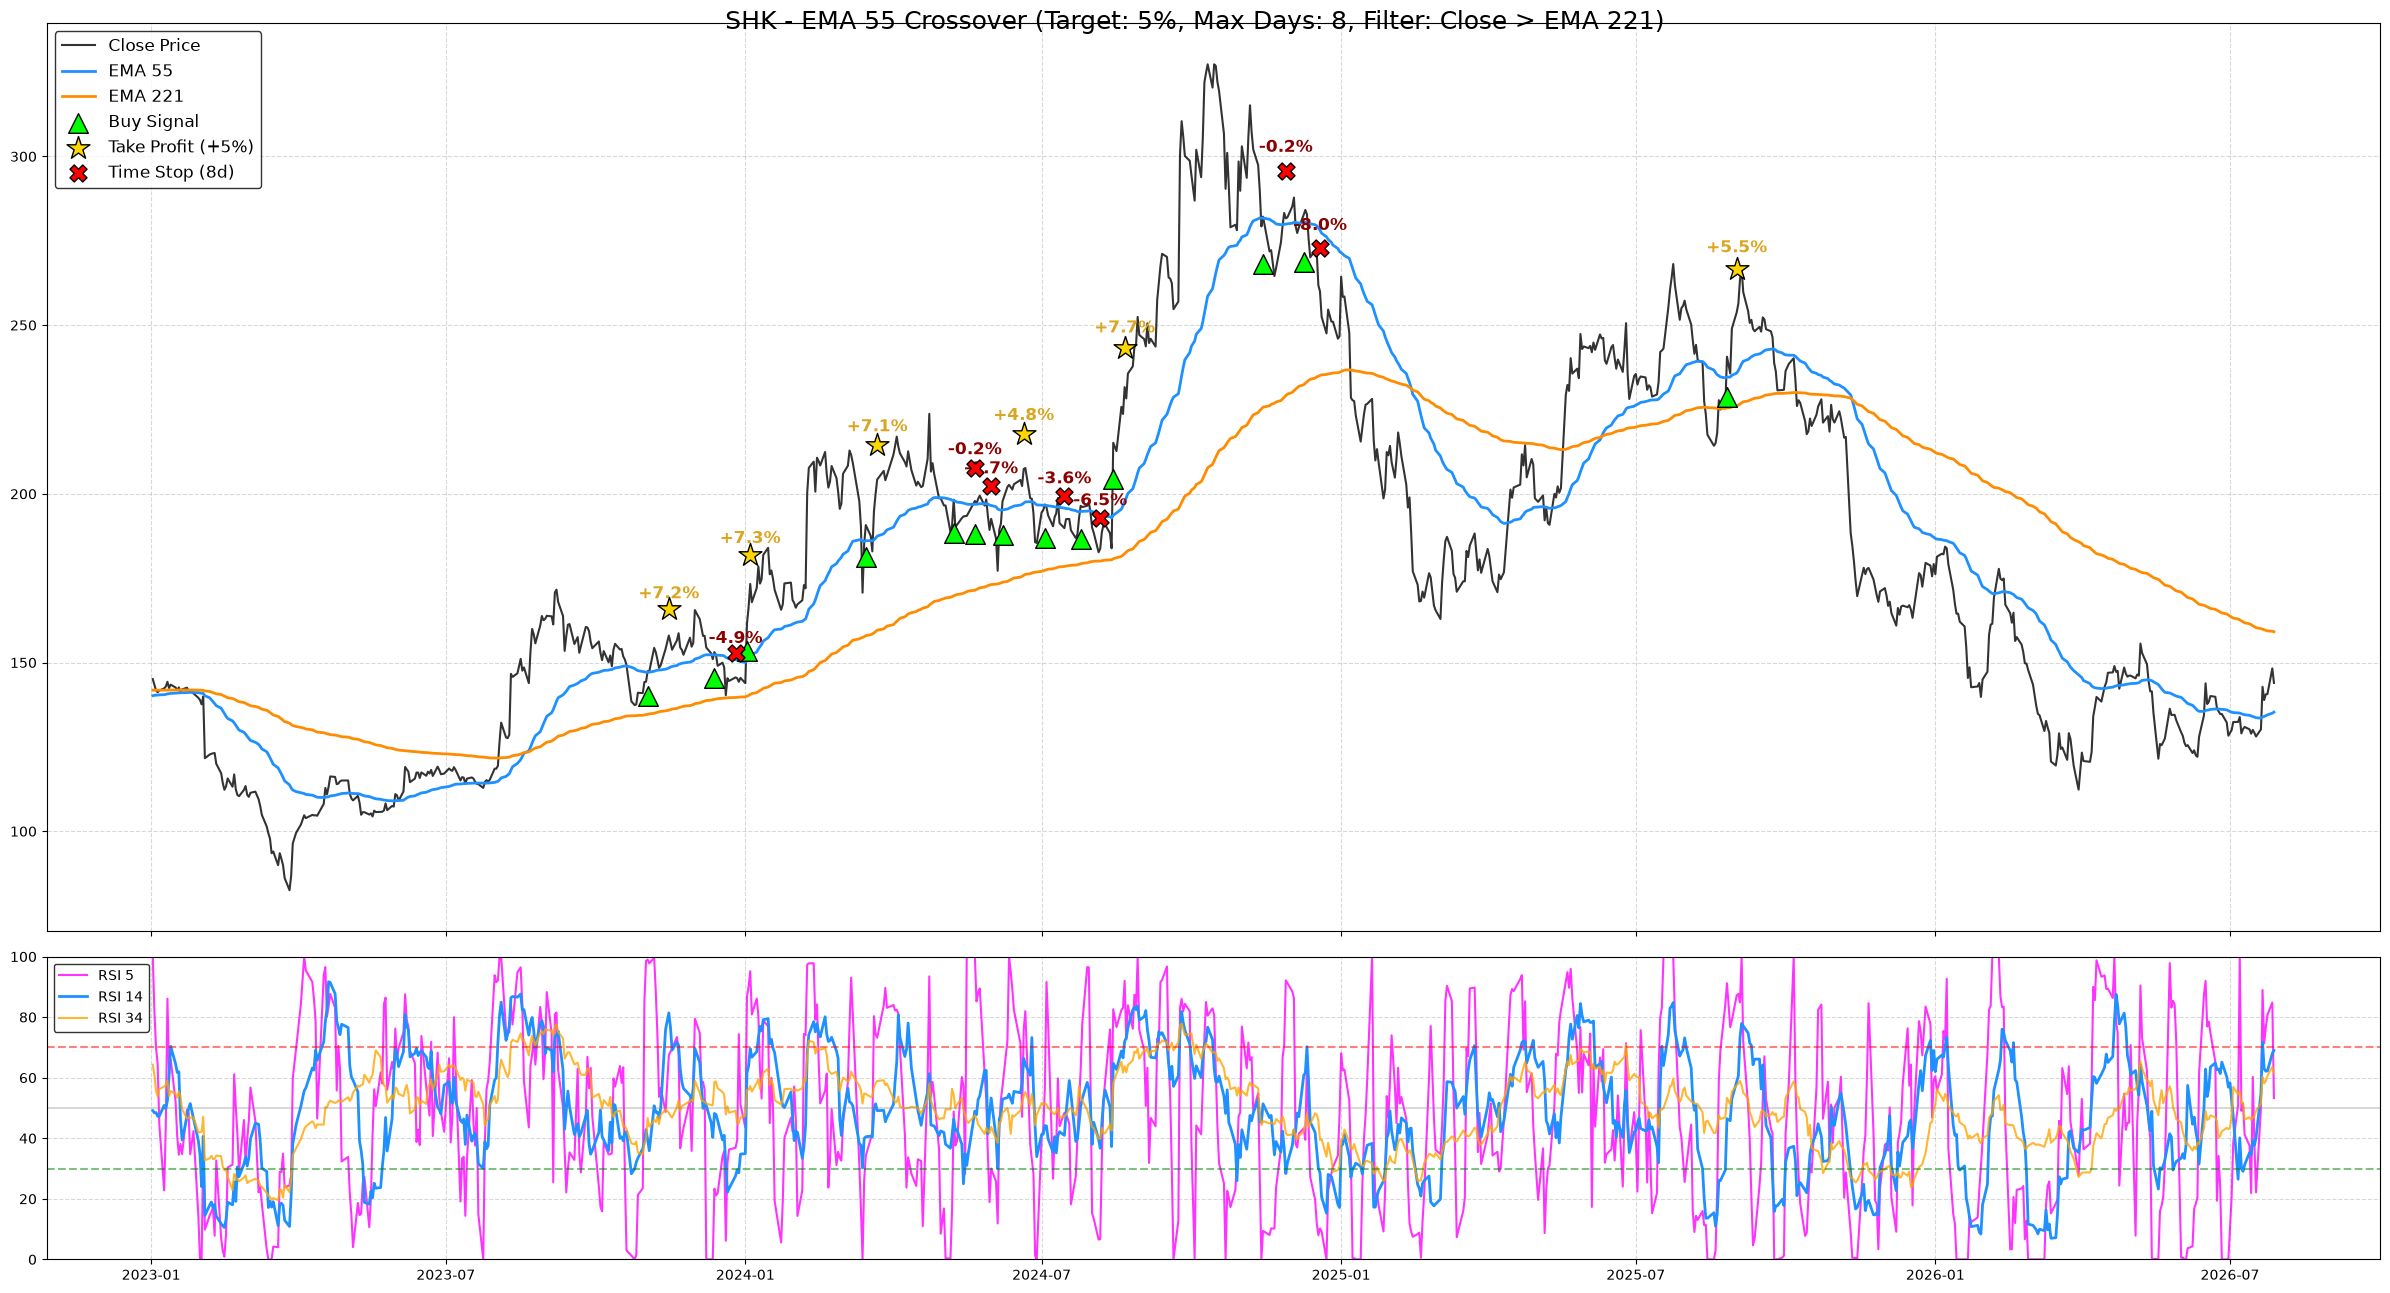

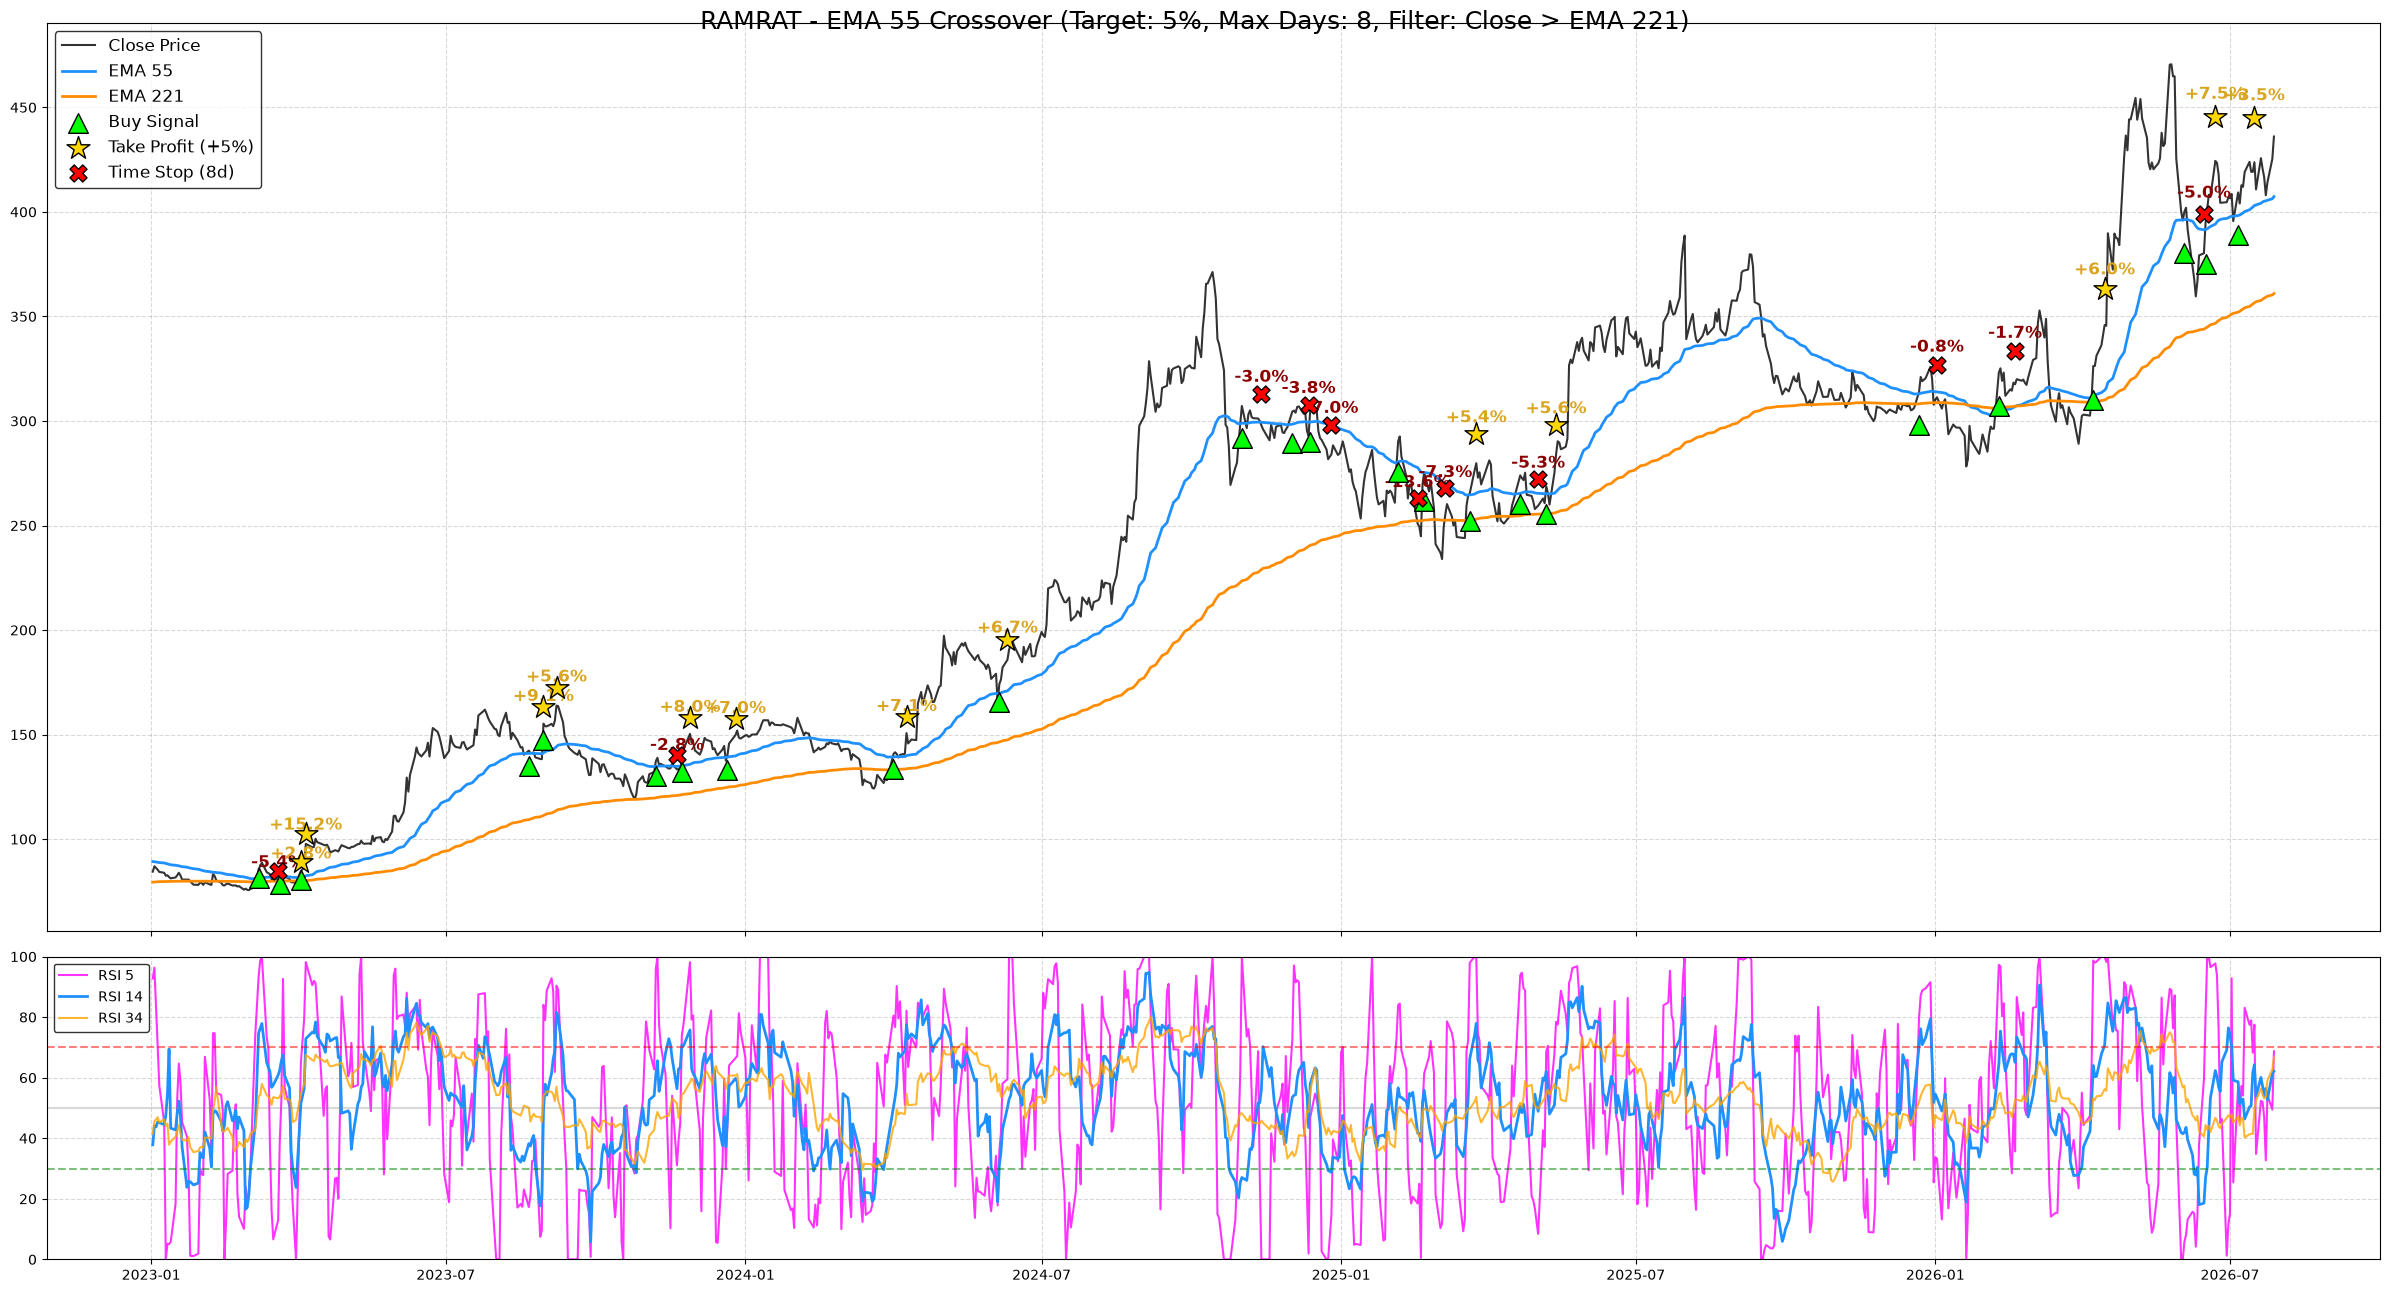

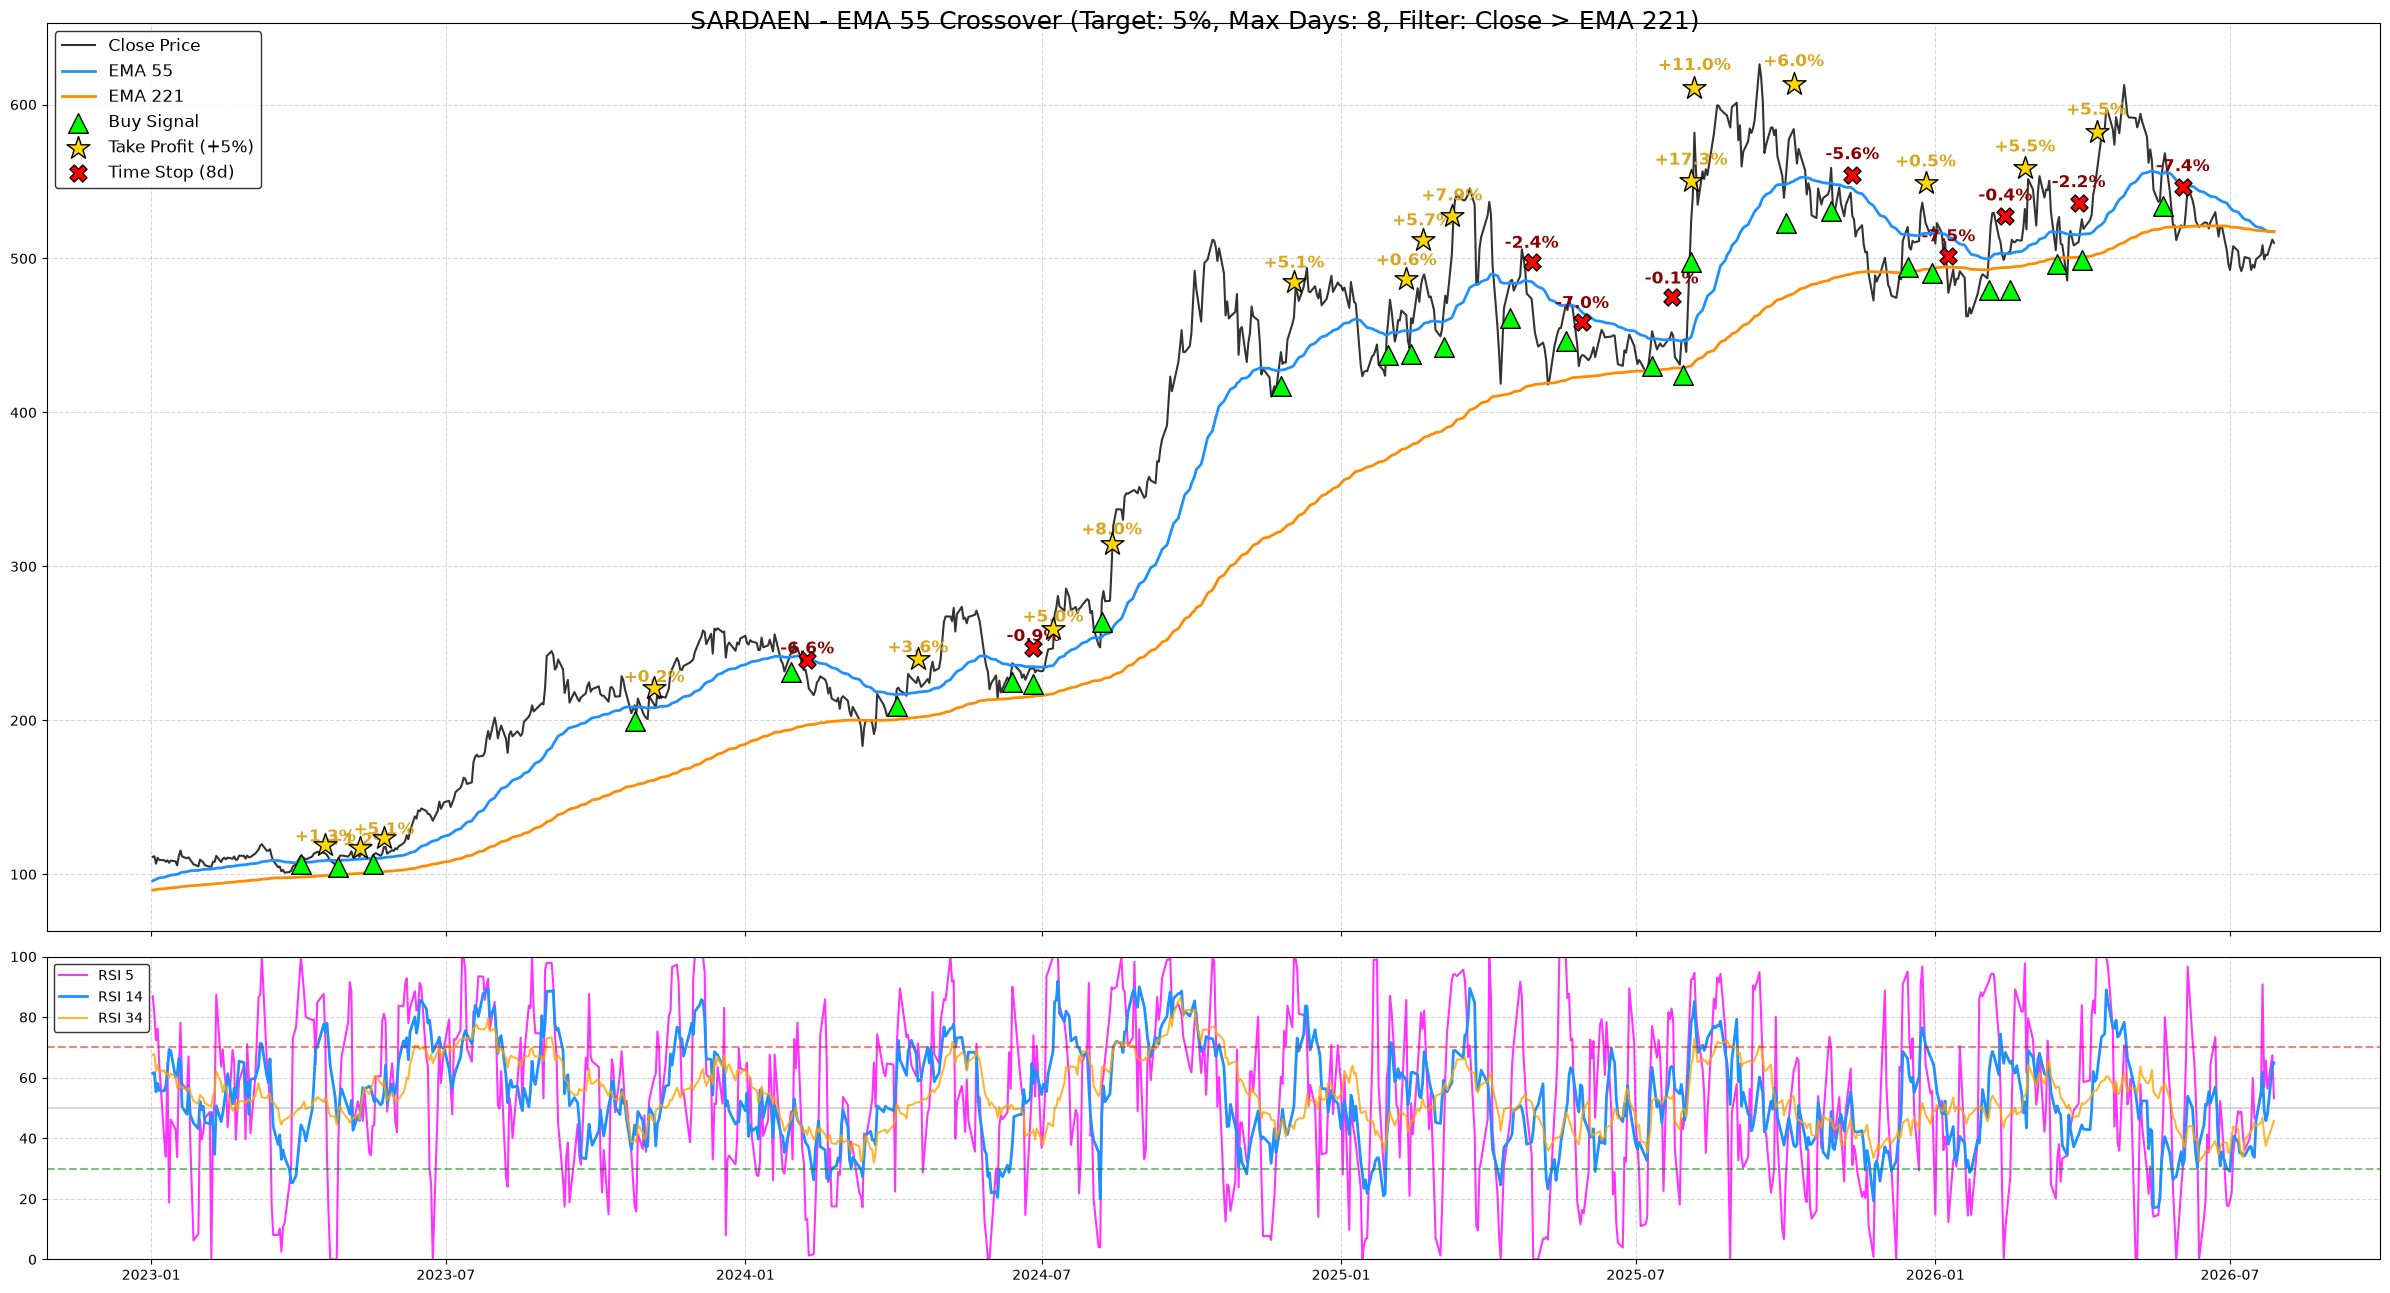

In [4]:
# 4. Matplotlib Charts with RSI Subplots
for df in all_data:
    symbol = df['Symbol'].iloc[0]
    trades_df = full_trades_df[full_trades_df['Symbol'] == symbol] if not full_trades_df.empty else pd.DataFrame()
    
    fig, (ax1, ax2) = plt.subplots(2, 1, gridspec_kw={'height_ratios': [3, 1]}, figsize=(24, 14), sharex=True)
    
    fig.suptitle(f'{symbol} - EMA 55 Crossover (Target: 5%, Max Days: 8, Filter: Close > EMA 221)', fontsize=18, y=0.92)
    
    # --- SUBPLOT 1: PRICE & EMA ---
    ax1.plot(df['Date'], df['Close'], label='Close Price', color='black', alpha=0.8)
    ax1.plot(df['Date'], df['EMA_55'], label='EMA 55', color='dodgerblue', linewidth=2)
    ax1.plot(df['Date'], df['EMA_221'], label='EMA 221', color='darkorange', linewidth=2)
    
    if not trades_df.empty:
        # Plot Entries
        ax1.scatter(trades_df['Entry_Date'], trades_df['Entry_Price'] * 0.95, 
                    marker='^', s=200, color='lime', edgecolors='black', label='Buy Signal', zorder=5)
        
        wins = trades_df[trades_df['Return'] > 0]
        losses = trades_df[trades_df['Return'] <= 0]
        
        # Plot Take Profits
        if not wins.empty:
            ax1.scatter(wins['Exit_Date'], wins['Exit_Price'] * 1.05, 
                        marker='*', s=300, color='gold', edgecolors='black', label='Take Profit (+5%)', zorder=5)
            for _, r in wins.iterrows():
                ax1.annotate(f"+{r['Return']*100:.1f}%", (r['Exit_Date'], r['Exit_Price'] * 1.07), 
                             color='goldenrod', fontsize=12, ha='center', weight='bold')
        
        # Plot Time Stops
        if not losses.empty:
            ax1.scatter(losses['Exit_Date'], losses['Exit_Price'] * 1.05, 
                        marker='X', s=150, color='red', edgecolors='black', label='Time Stop (8d)', zorder=5)
            for _, r in losses.iterrows():
                ax1.annotate(f"{r['Return']*100:.1f}%", (r['Exit_Date'], r['Exit_Price'] * 1.07), 
                             color='darkred', fontsize=12, ha='center', weight='bold')
                             
    ax1.grid(color='gray', linestyle='--', alpha=0.3)
    leg = ax1.legend(loc='upper left', fontsize=12, facecolor='white', edgecolor='black')
    for text in leg.get_texts(): text.set_color("black")
    
    # --- SUBPLOT 2: RSI ---
    ax2.plot(df['Date'], df['RSI_5'], label='RSI 5', color='magenta', linewidth=1.5, alpha=0.8)
    ax2.plot(df['Date'], df['RSI_14'], label='RSI 14', color='dodgerblue', linewidth=2)
    ax2.plot(df['Date'], df['RSI_34'], label='RSI 34', color='orange', linewidth=1.5, alpha=0.8)
    
    # RSI Reference Lines
    ax2.axhline(70, color='red', linestyle='--', alpha=0.5)
    ax2.axhline(30, color='green', linestyle='--', alpha=0.5)
    ax2.axhline(50, color='gray', linestyle='-', alpha=0.3)
    
    ax2.set_ylim(0, 100)
    ax2.grid(color='gray', linestyle='--', alpha=0.3)
    ax2.legend(loc='upper left', fontsize=10, facecolor='white', edgecolor='black')
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
